In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# TP de synthèse AFC - Raisons x Métiers
# Version complète, questions 1 à 13, avec 3 axes
# Respect des définitions du cours AFC-1-22-23
# =========================================================

# ---------------------------------------------------------
# DONNÉES (tableau de contingence du TP-cours.pdf)
# ---------------------------------------------------------
N = pd.DataFrame(
    [
        [22,  89,  71, 27, 22, 40, 24],   # Logement
        [1,   24,  23, 29, 8,  10, 13],   # Santé
        [20,  98,  49, 22, 26, 46, 22],   # Argent
        [4,   7,   7,  6,  1,  3,  5],    # Guerre
        [12, 117, 121, 65, 24, 57, 48],   # Travail
        [11,  79,  60, 41, 11, 34, 43],   # Choix
        [6,   22,  26, 23, 7,  14, 13]    # Chômage
    ],
    index=["Logement", "Santé", "Argent", "Guerre", "Travail", "Choix", "Chômage"],
    columns=["Cadre", "Libre", "Employé", "Responsable", "Ouvrier", "Technicien", "Agriculteur"]
)

print("\n================ TABLEAU DE CONTINGENCE N (RAISONS x MÉTIERS) ================\n")
print(N)

# ---------------------------------------------------------
# Quantités de base : n, F, masses r et c
# ---------------------------------------------------------
n = N.values.sum()
F = N / n
r = F.sum(axis=1)
c = F.sum(axis=0)

print("\n================ INFORMATIONS GÉNÉRALES ================\n")
print(f"Nombre total n = {n}\n")
print("Masses lignes r :")
print(r.round(6))
print("\nMasses colonnes c :")
print(c.round(6))


================ TABLEAU DE CONTINGENCE N (RAISONS x MÉTIERS) ================

          Cadre  Libre  Employé  Responsable  Ouvrier  Technicien  Agriculteur
Logement     22     89       71           27       22          40           24
Santé         1     24       23           29        8          10           13
Argent       20     98       49           22       26          46           22
Guerre        4      7        7            6        1           3            5
Travail      12    117      121           65       24          57           48
Choix        11     79       60           41       11          34           43
Chômage       6     22       26           23        7          14           13

================ INFORMATIONS GÉNÉRALES ================

Nombre total n = 1553

Masses lignes r :
Logement    0.189955
Santé       0.069543
Argent      0.182228
Guerre      0.021249
Travail     0.285898
Choix       0.179652
Chômage     0.071475
dtype: float64

Masses colonnes c :
Cadr

In [52]:
# =========================================================
# 1) PROFILS LIGNES ET PROFILS COLONNES
# =========================================================
# Profil ligne i : Ni. / (somme de la ligne i)
prof_l = N.div(N.sum(axis=1), axis=0)

# Profil colonne j : N.j / (somme de la colonne j)
prof_c = N.div(N.sum(axis=0), axis=1)

print("\n================ 1) PROFILS LIGNES (P_L) ==========================================================================\n")
print(prof_l.round(4))

print("\n================ 1) PROFILS COLONNES (P_C) =======================================================================\n")
print(prof_c.round(4))


================ 1) PROFILS LIGNES (P_L) ==========================================================================

           Cadre   Libre  Employé  Responsable  Ouvrier  Technicien  \
Logement  0.0746  0.3017   0.2407       0.0915   0.0746      0.1356   
Santé     0.0093  0.2222   0.2130       0.2685   0.0741      0.0926   
Argent    0.0707  0.3463   0.1731       0.0777   0.0919      0.1625   
Guerre    0.1212  0.2121   0.2121       0.1818   0.0303      0.0909   
Travail   0.0270  0.2635   0.2725       0.1464   0.0541      0.1284   
Choix     0.0394  0.2832   0.2151       0.1470   0.0394      0.1219   
Chômage   0.0541  0.1982   0.2342       0.2072   0.0631      0.1261   

          Agriculteur  
Logement       0.0814  
Santé          0.1204  
Argent         0.0777  
Guerre         0.1515  
Travail        0.1081  
Choix          0.1541  
Chômage        0.1171  

================ 1) PROFILS COLONNES (P_C) =======================================================================

    

In [ ]:
# =========================================================
# Construction de la matrice centrée-réduite Z
# Z = D_r^{-1/2} (F - r c^T) D_c^{-1/2}
# =========================================================
Dr_inv_sqrt = np.diag(1 / np.sqrt(r.values))
Dc_inv_sqrt = np.diag(1 / np.sqrt(c.values))

rcT = np.outer(r.values, c.values)   # produit r c^T
S = F.values - rcT                   # centrage (Khi-deux)
Z = Dr_inv_sqrt @ S @ Dc_inv_sqrt

# =========================================================
# SVD de Z : Z = U Δ V^T
# =========================================================
U, sing_vals, Vt = np.linalg.svd(Z, full_matrices=False)
Delta = np.diag(sing_vals)
V = Vt.T

eigvals = sing_vals**2
total_inertia = eigvals.sum()
tau = eigvals / total_inertia * 100      # taux d'inertie en %
taux_cumule = np.cumsum(tau)
axes_names = [f"Axe {k+1}" for k in range(len(eigvals))]

# =========================================================
# 2) TAUX D’INERTIES OBTENUS ET TAUX CUMULÉS
# =========================================================
inerties = pd.DataFrame({
    "Valeur_propre": eigvals,
    "Taux_inertie_%": tau,
    "Taux_cumule_%": taux_cumule
}, index=axes_names)

print("\n================ 2) INERTIES ET TAUX CUMULÉS ================\n")
print(inerties.round(4))



================ 2) INERTIES ET TAUX CUMULÉS ================

       Valeur_propre  Taux_inertie_%  Taux_cumule_%
Axe 1         0.0385         66.8045        66.8045
Axe 2         0.0071         12.3369        79.1414
Axe 3         0.0067         11.6528        90.7942
Axe 4         0.0048          8.3301        99.1243
Axe 5         0.0005          0.8383        99.9626
Axe 6         0.0000          0.0374       100.0000
Axe 7         0.0000          0.0000       100.0000


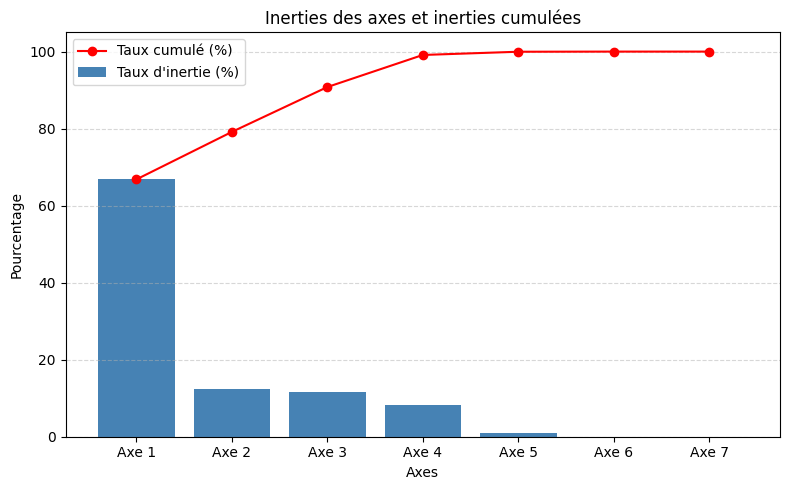


================ INTERPRÉTATION DES INERTIES (Q2–Q4) ================

- L’axe 1 explique 66.80% de l’inertie totale.
- L’axe 2 explique 12.34% de l’inertie totale.
- L’axe 3 explique 11.65% de l’inertie totale.
- Le cumul des axes 1 et 2 est de 79.14%,
  et le cumul des axes 1, 2 et 3 est de 90.79%.
=> Le plan (1,2) résume déjà une grande partie de l’information,
   mais l’ajout de l’axe 3 permet de dépasser 90% d’inertie,
   ce qui justifie d’examiner aussi les plans (1,3) et (2,3).


In [48]:
# =========================================================
# 3) GRAPHE DES INERTIES (BARRES + COURBE CUMULÉE)
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(axes_names, tau, color="steelblue", label="Taux d'inertie (%)")
plt.plot(axes_names, taux_cumule, color="red", marker="o", label="Taux cumulé (%)")
plt.xlabel("Axes")
plt.ylabel("Pourcentage")
plt.title("Inerties des axes et inerties cumulées")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
print("\n================ INTERPRÉTATION DES INERTIES (Q2–Q4) ================\n")
print(f"- L’axe 1 explique {tau[0]:.2f}% de l’inertie totale.")
print(f"- L’axe 2 explique {tau[1]:.2f}% de l’inertie totale.")
print(f"- L’axe 3 explique {tau[2]:.2f}% de l’inertie totale.")
print(f"- Le cumul des axes 1 et 2 est de {taux_cumule[1]:.2f}%,")
print(f"  et le cumul des axes 1, 2 et 3 est de {taux_cumule[2]:.2f}%.")
print("=> Le plan (1,2) résume déjà une grande partie de l’information,")
print("   mais l’ajout de l’axe 3 permet de dépasser 90% d’inertie,")
print("   ce qui justifie d’examiner aussi les plans (1,3) et (2,3).")



In [34]:
# =========================================================
# 4) CHOIX DES AXES 
# =========================================================
print("\n================ 4) CHOIX DES AXES ================\n")
print(f"Taux cumulé Axe1+Axe2 = {taux_cumule[1]:.2f}%")
print(f"Taux cumulé Axe1+Axe2+Axe3 = {taux_cumule[2]:.2f}%")



================ 4) CHOIX DES AXES ================

Taux cumulé Axe1+Axe2 = 79.14%
Taux cumulé Axe1+Axe2+Axe3 = 90.79%


In [35]:
# =========================================================
# 5) FACTEURS LIGNES φ_i (coordonnées factorielles lignes)
#    φ = D_r^{-1/2} U Δ
# =========================================================
Phi_full = Dr_inv_sqrt @ U @ Delta
Phi = pd.DataFrame(Phi_full[:, :3], index=N.index,
                   columns=["Axe 1", "Axe 2", "Axe 3"])

print("\n================ 5) FACTEURS LIGNES φ_i (axes 1,2,3) ================\n")
print(Phi.round(4))


================ 5) FACTEURS LIGNES φ_i (axes 1,2,3) ================

           Axe 1   Axe 2   Axe 3
Logement -0.1811 -0.0020  0.0039
Santé     0.3751 -0.0896 -0.1794
Argent   -0.2898 -0.0326 -0.0559
Guerre    0.0794 -0.3273  0.2226
Travail   0.0972  0.1022 -0.0062
Choix     0.1016 -0.0048  0.1228
Chômage   0.1872 -0.1237 -0.0435


In [36]:
# =========================================================
# 6) FACTEURS COLONNES ψ_j (coordonnées factorielles colonnes)
#    ψ = D_c^{-1/2} V Δ
# =========================================================
Psi_full = Dc_inv_sqrt @ V @ Delta
Psi = pd.DataFrame(Psi_full[:, :3], index=N.columns,
                   columns=["Axe 1", "Axe 2", "Axe 3"])

print("\n================ 6) FACTEURS COLONNES ψ_j (axes 1,2,3) ================\n")
print(Psi.round(4))


================ 6) FACTEURS COLONNES ψ_j (axes 1,2,3) ================

              Axe 1   Axe 2   Axe 3
Cadre       -0.3808 -0.2596  0.1116
Libre       -0.1337  0.0283  0.0041
Employé      0.0693  0.0919  0.0158
Responsable  0.3560 -0.0965 -0.0778
Ouvrier     -0.1892 -0.0482 -0.2072
Technicien  -0.1241  0.0274 -0.0195
Agriculteur  0.1826 -0.0336  0.1499


In [37]:
# =========================================================
# 7) MATRICE DES PROJECTIONS DES PROFILS-COLONNES SUR CHAQUE AXE
#    (ici, ce sont les coordonnées ψ_j sur les axes 1,2,3)
# =========================================================
print("\n================ 7) PROJECTIONS DES PROFILS-COLONNES (axes 1,2,3) ================\n")
print(Psi.round(4))


================ 7) PROJECTIONS DES PROFILS-COLONNES (axes 1,2,3) ================

              Axe 1   Axe 2   Axe 3
Cadre       -0.3808 -0.2596  0.1116
Libre       -0.1337  0.0283  0.0041
Employé      0.0693  0.0919  0.0158
Responsable  0.3560 -0.0965 -0.0778
Ouvrier     -0.1892 -0.0482 -0.2072
Technicien  -0.1241  0.0274 -0.0195
Agriculteur  0.1826 -0.0336  0.1499



================ 8) PLAN FACTORIEL (1,2) ================



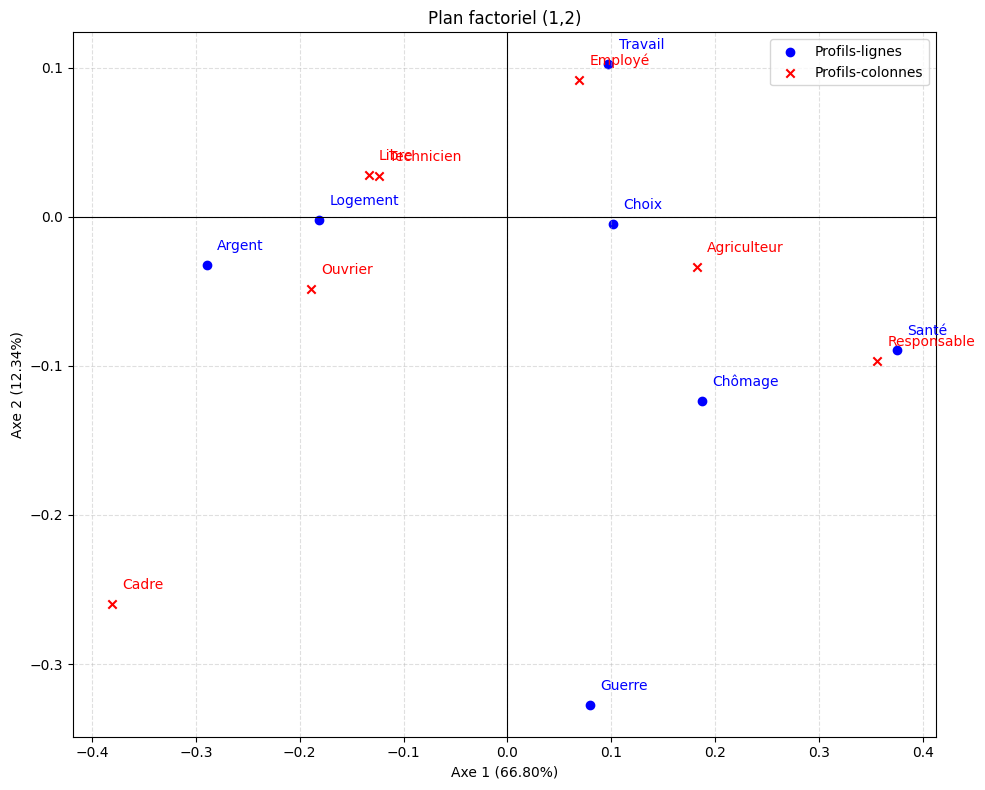


================ INTERPRÉTATION DU PLAN (1,2) ================

Modalités bien représentées sur le plan (1,2) (qualité élevée) :
- Lignes (raisons) :
Travail     0.950
Argent      0.914
Logement    0.834
Chômage     0.817
Santé       0.800
Guerre      0.607
Choix       0.313
dtype: float64

- Colonnes (métiers) :
Responsable    0.957
Cadre          0.867
Libre          0.828
Technicien     0.818
Employé        0.585
Agriculteur    0.545
Ouvrier        0.469
dtype: float64

Commentaires 
- Les raisons les mieux représentées sur le plan (1,2) sont par exemple Travail, Argent, Logement, Chômage,
  car leurs qualités de représentation sont élevées (proches ou supérieures à 0.8).
- Les raisons comme Choix ou Guerre sont moins bien représentées sur ce plan et doivent être interprétées avec prudence.
- Du côté des métiers, Responsable, Cadre, Libre et Technicien sont bien représentés sur (1,2),
  alors que Employé, Ouvrier, Agriculteur sont moins bien représentés et nécessitent plus de préca

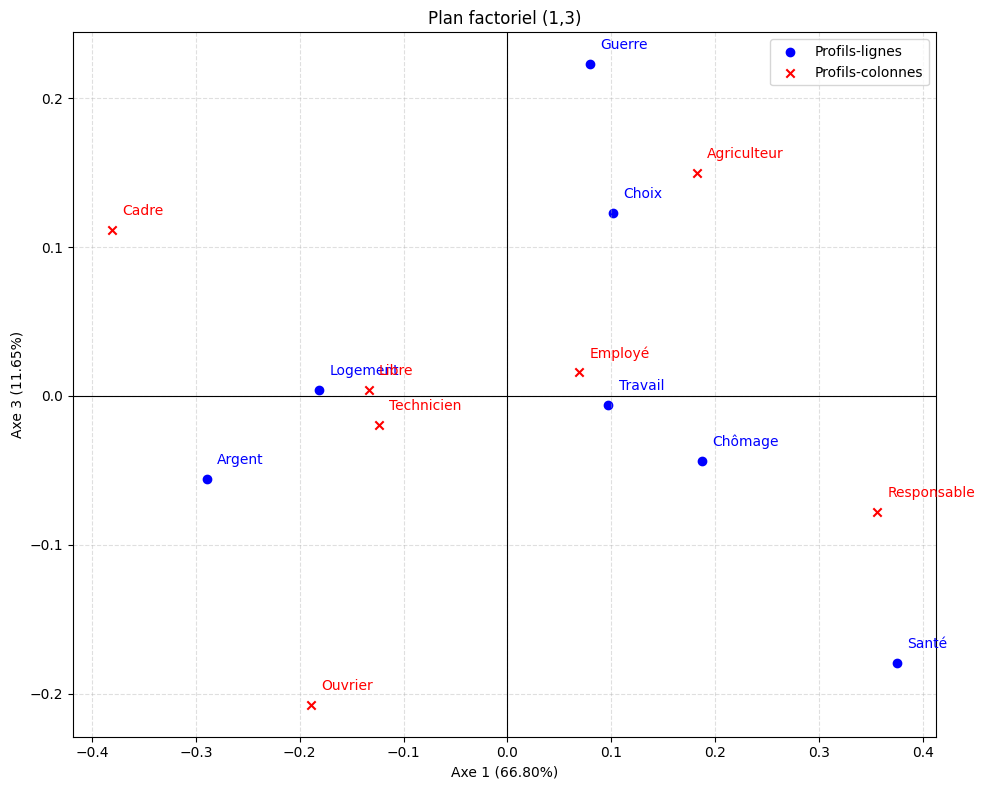


================ INTERPRÉTATION DU PLAN (1,3) ================

Qualité de représentation sur le plan (1,3) :
- Lignes (raisons) :
Argent      0.936
Santé       0.930
Logement    0.834
Choix       0.769
Chômage     0.599
Travail     0.453
Guerre      0.299
dtype: float64

- Colonnes (métiers) :
Ouvrier        0.967
Responsable    0.934
Agriculteur    0.882
Technicien     0.799
Libre          0.793
Cadre          0.643
Employé        0.223
dtype: float64

Commentaires  :
- Sur le plan (1,3), certaines modalités qui étaient moyennement représentées sur (1,2)
  peuvent être mieux représentées, par exemple Santé, Argent ou Choix si leurs qualités augmentent.
- Du côté des métiers, on peut observer que Ouvrier et Agriculteur sont très bien représentés sur (1,3),
  ce qui permet d’affiner l’interprétation pour ces métiers.

Analyse géométrique sur le plan (1,3) :
- L’axe 1 conserve le même sens que sur (1,2).
- L’axe 3 apporte une nouvelle opposition : certaines raisons (par exemple Guerre 

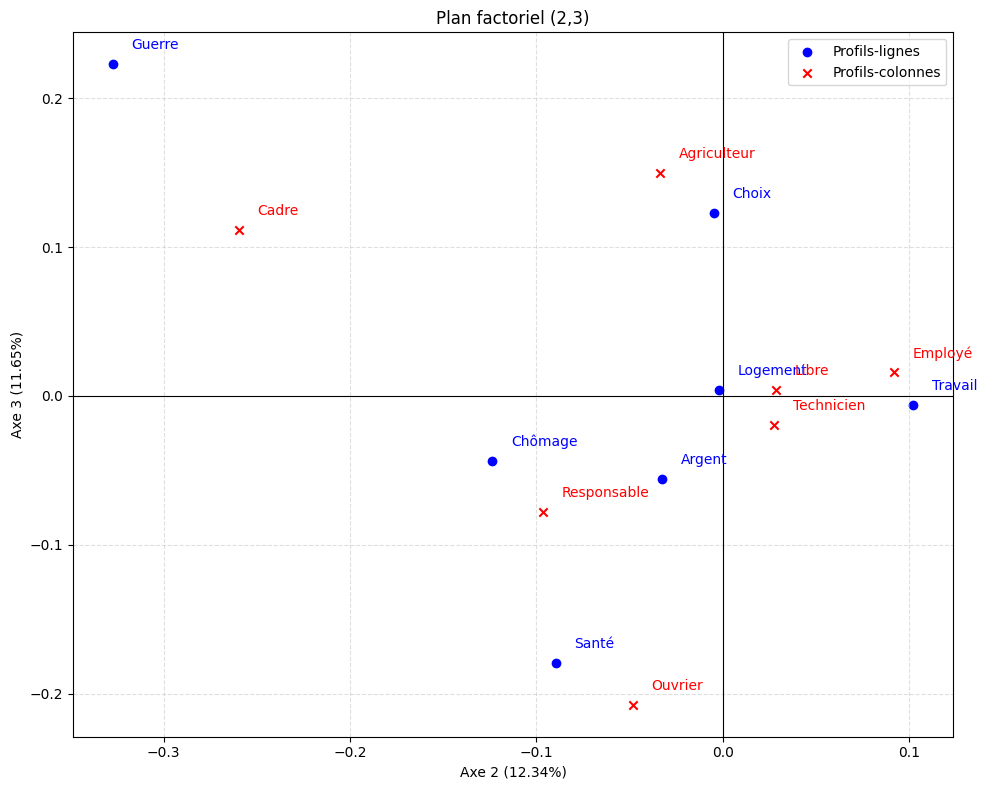


================ INTERPRÉTATION DU PLAN (2,3) ================

Qualité de représentation sur le plan (2,3) :
- Lignes (raisons) :
Guerre      0.839
Travail     0.500
Choix       0.457
Chômage     0.279
Santé       0.216
Argent      0.045
Logement    0.000
dtype: float64

- Colonnes (métiers) :
Ouvrier        0.556
Employé        0.384
Agriculteur    0.373
Cadre          0.326
Responsable    0.108
Technicien     0.057
Libre          0.036
dtype: float64

Commentaires  :
- Le plan (2,3) est surtout utile pour les modalités qui sont mal représentées sur l’axe 1,
  mais qui ont des cos² importants sur les axes 2 et 3 (par exemple Guerre, Choix, certains métiers…).
- Ce plan met en avant des oppositions plus secondaires, complétant l’analyse du plan (1,2).

Analyse géométrique sur le plan (2,3) :
- L’axe 2 peut opposer des raisons comme Guerre et Chômage à d’autres raisons,
  tandis que l’axe 3 met en avant des modalités comme Ouvrier, Agriculteur ou Choix,
  selon leurs coordonnées facto

In [51]:
# =========================================================
# 8) VISUALISATION DES DEUX NUAGES SUR LES PLANS (1,2), (1,3), (2,3)
# =========================================================
def plot_plan(a, b, Phi, Psi, tau):
    ax1 = a - 1
    ax2 = b - 1
    plt.figure(figsize=(10, 8))

    # Nuage des profils-lignes
    plt.scatter(Phi.iloc[:, ax1], Phi.iloc[:, ax2],
                color="blue", label="Profils-lignes")
    for label in Phi.index:
        plt.text(Phi.iloc[Phi.index.get_loc(label), ax1] + 0.01,
                 Phi.iloc[Phi.index.get_loc(label), ax2] + 0.01,
                 label, color="blue")

    # Nuage des profils-colonnes
    plt.scatter(Psi.iloc[:, ax1], Psi.iloc[:, ax2],
                color="red", marker="x", label="Profils-colonnes")
    for label in Psi.index:
        plt.text(Psi.iloc[Psi.index.get_loc(label), ax1] + 0.01,
                 Psi.iloc[Psi.index.get_loc(label), ax2] + 0.01,
                 label, color="red")

    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel(f"Axe {a} ({tau[ax1]:.2f}%)")
    plt.ylabel(f"Axe {b} ({tau[ax2]:.2f}%)")
    plt.title(f"Plan factoriel ({a},{b})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n================ 8) PLAN FACTORIEL (1,2) ================\n")
plot_plan(1, 2, Phi, Psi, tau)
# ------------------- Plan (1,2) -------------------
print("\n================ INTERPRÉTATION DU PLAN (1,2) ================\n")

print("Modalités bien représentées sur le plan (1,2) (qualité élevée) :")
print("- Lignes (raisons) :")
print(qual_l_12.sort_values(ascending=False).round(3))
print("\n- Colonnes (métiers) :")
print(qual_c_12.sort_values(ascending=False).round(3))

print("\nCommentaires ")
print("- Les raisons les mieux représentées sur le plan (1,2) sont par exemple Travail, Argent, Logement, Chômage,")
print("  car leurs qualités de représentation sont élevées (proches ou supérieures à 0.8).")
print("- Les raisons comme Choix ou Guerre sont moins bien représentées sur ce plan et doivent être interprétées avec prudence.")
print("- Du côté des métiers, Responsable, Cadre, Libre et Technicien sont bien représentés sur (1,2),")
print("  alors que Employé, Ouvrier, Agriculteur sont moins bien représentés et nécessitent plus de précautions.")

print("\nAnalyse géométrique sur le plan (1,2) :")
print("- L’axe 1 oppose principalement des raisons comme Santé, Chômage, Travail (coordonnées positives sur l’axe 1),")
print("  aux raisons comme Argent et Logement (coordonnées négatives sur l’axe 1).")
print("- Du côté des métiers, l’axe 1 oppose surtout Responsable et Agriculteur (coordonnées positives),")
print("  à Cadre, Libre, Ouvrier et Technicien (coordonnées négatives).")
print("- Les proximités sur le graphique permettent d’associer certaines raisons à certains métiers :")
print("  par exemple, si Santé ou Chômage sont situées du même côté que Responsable,")
print("  cela suggère que ces raisons sont relativement plus fréquentes chez les responsables, etc.")
print("- Les points proches de l’origine (coordonnées faibles sur les deux axes) sont peu discriminants.")

print("\n================ 8) PLAN FACTORIEL (1,3) ================\n")
plot_plan(1, 3, Phi, Psi, tau)

# ------------------- Plan (1,3) -------------------
print("\n================ INTERPRÉTATION DU PLAN (1,3) ================\n")

print("Qualité de représentation sur le plan (1,3) :")
print("- Lignes (raisons) :")
print(qual_l_13.sort_values(ascending=False).round(3))
print("\n- Colonnes (métiers) :")
print(qual_c_13.sort_values(ascending=False).round(3))

print("\nCommentaires  :")
print("- Sur le plan (1,3), certaines modalités qui étaient moyennement représentées sur (1,2)")
print("  peuvent être mieux représentées, par exemple Santé, Argent ou Choix si leurs qualités augmentent.")
print("- Du côté des métiers, on peut observer que Ouvrier et Agriculteur sont très bien représentés sur (1,3),")
print("  ce qui permet d’affiner l’interprétation pour ces métiers.")

print("\nAnalyse géométrique sur le plan (1,3) :")
print("- L’axe 1 conserve le même sens que sur (1,2).")
print("- L’axe 3 apporte une nouvelle opposition : certaines raisons (par exemple Guerre ou Choix)")
print("  peuvent se distinguer fortement sur l’axe 3, même si elles étaient moins visibles sur l’axe 2.")
print("- On peut commenter quelles raisons et quels métiers sont en haut/bas de l’axe 3 et bien représentés,")
print("  afin de décrire ce que cet axe supplémentaire apporte comme information.")
print("\n================ 8) PLAN FACTORIEL (2,3) ================\n")
plot_plan(2, 3, Phi, Psi, tau)

print("\n================ INTERPRÉTATION DU PLAN (2,3) ================\n")

print("Qualité de représentation sur le plan (2,3) :")
print("- Lignes (raisons) :")
print(qual_l_23.sort_values(ascending=False).round(3))
print("\n- Colonnes (métiers) :")
print(qual_c_23.sort_values(ascending=False).round(3))

print("\nCommentaires  :")
print("- Le plan (2,3) est surtout utile pour les modalités qui sont mal représentées sur l’axe 1,")
print("  mais qui ont des cos² importants sur les axes 2 et 3 (par exemple Guerre, Choix, certains métiers…).")
print("- Ce plan met en avant des oppositions plus secondaires, complétant l’analyse du plan (1,2).")

print("\nAnalyse géométrique sur le plan (2,3) :")
print("- L’axe 2 peut opposer des raisons comme Guerre et Chômage à d’autres raisons,")
print("  tandis que l’axe 3 met en avant des modalités comme Ouvrier, Agriculteur ou Choix,")
print("  selon leurs coordonnées factorielles.")
print("- On interprète ce plan uniquement pour les modalités bien représentées (qualité élevée sur (2,3)).")

In [40]:
# =========================================================
# 9) CONTRIBUTIONS ABSOLUES ET RELATIVES (cos²) DES PROFILS-LIGNES
# =========================================================
K, J = N.shape
A = len(eigvals)
r_arr = r.values.reshape(-1, 1)
lambda_arr = eigvals.reshape(1, -1)

phi_all = Phi_full

# contributions absolues des lignes : (r_i * phi_ik^2) / lambda_k
contrib_rows = (r_arr * (phi_all**2)) / lambda_arr
contrib_rows_123 = contrib_rows[:, :3]
contrib_rows_df = pd.DataFrame(contrib_rows_123, index=N.index,
                               columns=["Axe 1", "Axe 2", "Axe 3"])

# cos² (qualité) des lignes : phi_ik^2 / d_i^2
d2_rows = (phi_all**2).sum(axis=1).reshape(-1, 1)
cos2_rows = (phi_all**2) / d2_rows
cos2_rows_123 = cos2_rows[:, :3]
cos2_rows_df = pd.DataFrame(cos2_rows_123, index=N.index,
                            columns=["Axe 1", "Axe 2", "Axe 3"])

print("\n================ 9) CONTRIBUTIONS ABSOLUES PROFILS-LIGNES (axes 1,2,3) ================\n")
print(contrib_rows_df.round(4))

print("\n================ 9) COS² (QUALITÉ) PROFILS-LIGNES (axes 1,2,3) ================\n")
print(cos2_rows_df.round(4))


================ 9) CONTRIBUTIONS ABSOLUES PROFILS-LIGNES (axes 1,2,3) ================

           Axe 1   Axe 2   Axe 3
Logement  0.1617  0.0001  0.0004
Santé     0.2541  0.0785  0.3333
Argent    0.3974  0.0272  0.0847
Guerre    0.0035  0.3200  0.1567
Travail   0.0702  0.4197  0.0016
Choix     0.0481  0.0006  0.4031
Chômage   0.0650  0.1539  0.0201

================ 9) COS² (QUALITÉ) PROFILS-LIGNES (axes 1,2,3) ================

           Axe 1   Axe 2   Axe 3
Logement  0.8339  0.0001  0.0004
Santé     0.7567  0.0432  0.1732
Argent    0.9024  0.0114  0.0336
Guerre    0.0338  0.5734  0.2653
Travail   0.4516  0.4985  0.0018
Choix     0.3126  0.0007  0.4567
Chômage   0.5687  0.2484  0.0306


In [42]:
# =========================================================
# 10) CONTRIBUTIONS ABSOLUES ET cos² DES PROFILS-COLONNES
# =========================================================
c_arr = c.values.reshape(-1, 1)
psi_all = Psi_full

contrib_cols = (c_arr * (psi_all**2)) / lambda_arr
contrib_cols_123 = contrib_cols[:, :3]
contrib_cols_df = pd.DataFrame(contrib_cols_123, index=N.columns,
                               columns=["Axe 1", "Axe 2", "Axe 3"])

d2_cols = (psi_all**2).sum(axis=1).reshape(-1, 1)
cos2_cols = (psi_all**2) / d2_cols
cos2_cols_123 = cos2_cols[:, :3]
cos2_cols_df = pd.DataFrame(cos2_cols_123, index=N.columns,
                            columns=["Axe 1", "Axe 2", "Axe 3"])

print("\n================ 10) CONTRIBUTIONS ABSOLUES PROFILS-COLONNES (axes 1,2,3) ================\n")
print(contrib_cols_df.round(4))

print("\n================ 10) COS² (QUALITÉ) PROFILS-COLONNES (axes 1,2,3) ================\n")
print(cos2_cols_df.round(4))




================ 10) CONTRIBUTIONS ABSOLUES PROFILS-COLONNES (axes 1,2,3) ================

              Axe 1   Axe 2   Axe 3
Cadre        0.1842  0.4639  0.0907
Libre        0.1302  0.0315  0.0007
Employé      0.0287  0.2730  0.0085
Responsable  0.4514  0.1797  0.1235
Ouvrier      0.0593  0.0209  0.4075
Technicien   0.0525  0.0139  0.0074
Agriculteur  0.0937  0.0172  0.3616

================ 10) COS² (QUALITÉ) PROFILS-COLONNES (axes 1,2,3) ================

              Axe 1   Axe 2   Axe 3
Cadre        0.5917  0.2751  0.0508
Libre        0.7922  0.0354  0.0007
Employé      0.2123  0.3731  0.0110
Responsable  0.8917  0.0656  0.0426
Ouvrier      0.4399  0.0286  0.5276
Technicien   0.7798  0.0380  0.0193
Agriculteur  0.5270  0.0178  0.3548


In [43]:
# =========================================================
# 11) MODALITÉS MAL REPRÉSENTÉES SUR LES PLANS (1,2), (1,3), (2,3)
# =========================================================
qual_l_12 = cos2_rows_df[["Axe 1", "Axe 2"]].sum(axis=1)
qual_c_12 = cos2_cols_df[["Axe 1", "Axe 2"]].sum(axis=1)

qual_l_13 = cos2_rows_df[["Axe 1", "Axe 3"]].sum(axis=1)
qual_c_13 = cos2_cols_df[["Axe 1", "Axe 3"]].sum(axis=1)

qual_l_23 = cos2_rows_df[["Axe 2", "Axe 3"]].sum(axis=1)
qual_c_23 = cos2_cols_df[["Axe 2", "Axe 3"]].sum(axis=1)

print("\n================ 11) QUALITÉ DE REPRÉSENTATION LIGNES PLAN (1,2) ================\n")
print(qual_l_12.round(4))

print("\n================ 11) QUALITÉ DE REPRÉSENTATION COLONNES PLAN (1,2) ================\n")
print(qual_c_12.round(4))

print("\n(Extension) QUALITÉ LIGNES PLAN (1,3) :\n")
print(qual_l_13.round(4))

print("\n(Extension) QUALITÉ COLONNES PLAN (1,3) :\n")
print(qual_c_13.round(4))

print("\n(Extension) QUALITÉ LIGNES PLAN (2,3) :\n")
print(qual_l_23.round(4))

print("\n(Extension) QUALITÉ COLONNES PLAN (2,3) :\n")
print(qual_c_23.round(4))

print("\nPour Q11 : les modalités avec les plus petites qualités sur un plan sont dites mal représentées sur ce plan.")


================ 11) QUALITÉ DE REPRÉSENTATION LIGNES PLAN (1,2) ================

Logement    0.8341
Santé       0.7999
Argent      0.9138
Guerre      0.6072
Travail     0.9501
Choix       0.3133
Chômage     0.8171
dtype: float64

================ 11) QUALITÉ DE REPRÉSENTATION COLONNES PLAN (1,2) ================

Cadre          0.8669
Libre          0.8276
Employé        0.5854
Responsable    0.9573
Ouvrier        0.4685
Technicien     0.8177
Agriculteur    0.5448
dtype: float64

(Extension) QUALITÉ LIGNES PLAN (1,3) :

Logement    0.8343
Santé       0.9299
Argent      0.9359
Guerre      0.2990
Travail     0.4534
Choix       0.7693
Chômage     0.5993
dtype: float64

(Extension) QUALITÉ COLONNES PLAN (1,3) :

Cadre          0.6425
Libre          0.7929
Employé        0.2233
Responsable    0.9343
Ouvrier        0.9675
Technicien     0.7990
Agriculteur    0.8818
dtype: float64

(Extension) QUALITÉ LIGNES PLAN (2,3) :

Logement    0.0005
Santé       0.2164
Argent      0.0450
Guerre     

In [46]:
# =========================================================
# 12) RAISONS ET MÉTIERS CONTRIBUANT FORTEMENT AU PREMIER AXE
# =========================================================
contrib_rows_axis1 = contrib_rows_df["Axe 1"].sort_values(ascending=False)
contrib_cols_axis1 = contrib_cols_df["Axe 1"].sort_values(ascending=False)

print("\n================ 12) RAISONS LES PLUS CONTRIBUTIVES À L’AXE 1 ================\n")
print(contrib_rows_axis1.round(4))

print("\n================ 12) MÉTIERS LES PLUS CONTRIBUTIFS À L’AXE 1 ================\n")
print(contrib_cols_axis1.round(4))

# ------------------- Q12 : Raisons et métiers contribuant fortement à l’axe 1 -------------------
print("\n================ INTERPRÉTATION Q12 (AXE 1) ================\n")

print("Raisons les plus contributives à l’axe 1 :")
print(contrib_rows_axis1.round(4))

print("\nMétiers les plus contributifs à l’axe 1 :")
print(contrib_cols_axis1.round(4))

print("\nCommentaires (à adapter) :")
print("- L’axe 1 est principalement défini par les raisons 'Argent' et 'Santé',")
print("  suivies de 'Logement', car ce sont elles qui ont les contributions les plus élevées.")
print("- Du côté des métiers, l’axe 1 est surtout défini par 'Responsable' et 'Cadre',")
print("  puis par 'Libre' et 'Agriculteur'.")
print("- On peut donc interpréter l’axe 1 comme opposant certaines raisons économiques ou de santé,")
print("  associées à des métiers de type responsables/cadres, à d’autres raisons associées à d’autres catégories sociales.")


================ 12) RAISONS LES PLUS CONTRIBUTIVES À L’AXE 1 ================

Argent      0.3974
Santé       0.2541
Logement    0.1617
Travail     0.0702
Chômage     0.0650
Choix       0.0481
Guerre      0.0035
Name: Axe 1, dtype: float64

================ 12) MÉTIERS LES PLUS CONTRIBUTIFS À L’AXE 1 ================

Responsable    0.4514
Cadre          0.1842
Libre          0.1302
Agriculteur    0.0937
Ouvrier        0.0593
Technicien     0.0525
Employé        0.0287
Name: Axe 1, dtype: float64

================ INTERPRÉTATION Q12 (AXE 1) ================

Raisons les plus contributives à l’axe 1 :
Argent      0.3974
Santé       0.2541
Logement    0.1617
Travail     0.0702
Chômage     0.0650
Choix       0.0481
Guerre      0.0035
Name: Axe 1, dtype: float64

Métiers les plus contributifs à l’axe 1 :
Responsable    0.4514
Cadre          0.1842
Libre          0.1302
Agriculteur    0.0937
Ouvrier        0.0593
Technicien     0.0525
Employé        0.0287
Name: Axe 1, dtype: float64

Com

In [47]:
# ------------------- Q13 : Synthèse générale -------------------
print("\n================ INTERPRÉTATION GLOBALE (Q13) ================\n")
print("En synthèse :")
print("- L’axe 1 porte l’opposition principale entre les différentes raisons (Argent, Santé, Logement, etc.)")
print("  et les catégories sociales (Responsable, Cadre, Libre, etc.).")
print("- Les axes 2 et 3 apportent des nuances supplémentaires, en mettant en avant certaines raisons")
print("  comme Guerre ou Choix et certains métiers comme Ouvrier ou Agriculteur.")
print("- Les proximités sur le plan (1,2) permettent d’identifier des couples raison/métier qui sont")
print("  relativement associés dans les données de l’enquête.")
print("- Les modalités mal représentées sur un plan donné doivent être interprétées avec prudence et,")
print("  si nécessaire, analysées sur un autre plan (par exemple (1,3) ou (2,3)).")
print("- L’ensemble de l’analyse permet de décrire les relations entre la situation sociale des parents")
print("  (les métiers) et les raisons pour lesquelles ces familles n’ont pas d’enfants.")


================ INTERPRÉTATION GLOBALE (Q13) ================

En synthèse :
- L’axe 1 porte l’opposition principale entre les différentes raisons (Argent, Santé, Logement, etc.)
  et les catégories sociales (Responsable, Cadre, Libre, etc.).
- Les axes 2 et 3 apportent des nuances supplémentaires, en mettant en avant certaines raisons
  comme Guerre ou Choix et certains métiers comme Ouvrier ou Agriculteur.
- Les proximités sur le plan (1,2) permettent d’identifier des couples raison/métier qui sont
  relativement associés dans les données de l’enquête.
- Les modalités mal représentées sur un plan donné doivent être interprétées avec prudence et,
  si nécessaire, analysées sur un autre plan (par exemple (1,3) ou (2,3)).
- L’ensemble de l’analyse permet de décrire les relations entre la situation sociale des parents
  (les métiers) et les raisons pour lesquelles ces familles n’ont pas d’enfants.
